In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Data Loading
df = pd.read_csv('data_incentive_attitudes.csv')

# Some basic data preprocessing steps
df = df.drop('Unnamed: 0', axis='columns')
df = df.rename(columns={'pubcost':'traincost', 
                   'pubtime':'traintime', 
                   'pubavail':'trainavail',
                    'bicycleincentive':'bikeincentive'})

df.head()

,user_id,trip_id,departure_time,arrival_time,Purpose,buscost,bustime,carcost,cartime,cardistance,...,SEX,AGE,INCOME,recco,information,incentivezone,value,task,job_type,income_con
0,20006,99545,10/28/2020 17:51,10/28/2020 19:21,101,770,69.4,151.7,43.72,15.17,...,1,36,4,2,only enviro,0,1,1,company employee,9000000
1,20006,100663,10/29/2020 17:58,10/29/2020 19:14,101,690,66.2,128.6,38.96,12.86,...,1,36,4,2,only enviro,0,1,2,company employee,9000000
2,20006,101712,10/30/2020 17:39,10/30/2020 19:05,101,770,69.4,151.7,43.72,15.17,...,1,36,4,1,no info,0,1,3,company employee,9000000
3,20006,101878,10/30/2020 21:00,10/30/2020 21:25,998,500,56.2,118.5,29.53,11.85,...,1,36,4,1,no info,0,1,4,company employee,9000000
4,20006,100936,10/30/2020 7:14,10/30/2020 8:29,100,770,69.4,151.7,43.72,15.17,...,1,36,4,1,no info,0,1,5,company employee,9000000


In [3]:
# What is `recco`?

In [4]:
basic_variables = list(df.columns)[:5]

purpose_code_dict = {100: 'Commuting to work / school',
                    101: 'Go Home',
                    200: 'Shopping for daily necessities',
                    201: 'Shopping other than daily necessities',
                    202: 'Meals and entertainment',
                    300: 'business',
                    400: 'Outpatient',
                    500: 'Pick-up and drop-off',
                    600: 'Sightseeing / Leisure',
                    998: 'others'}

alternative_specific_variables = list(df.columns)[5:29]
alternative_specific_variables.remove('mode')

attitudinal_variables = list(df.columns)[29:-10]
generic_variables = ['SEX', 'AGE', 'INCOME', 'job_type', 'information']

# <ins><b>Data Preprocessing</b></ins>

## Feature Encoding

In [5]:
from sklearn.preprocessing import OneHotEncoder
from datetime import datetime

In [6]:
ohe = OneHotEncoder()

In [7]:
# utility functions for extracting time-zones and trip duration information from arrival and departure times of a trip.

def get_trip_duration(df):
    """
    Returns the total minutes a trip lasted given its departure and arrival datetimes.
    """
    dep_datetime = datetime.strptime(df['departure_time'], '%m/%d/%Y %H:%M')
    arr_datetime = datetime.strptime(df['arrival_time'], '%m/%d/%Y %H:%M')
    
    return int((arr_datetime - dep_datetime).total_seconds()/60)

def get_day_zones(trip_datetime):
    """
    Divides the time into 4 zones and ordinally encoding them.
    Early morning (00:00 to 6:00) - 1
    AM peak (6:00 to 10:00) - 2
    Off peak (10:00 to 16:00) - 3
    PM peak (16:00 to 20:00) - 4
    Evening (20:00 to 00:00) - 5
    """
    dep_hrs, dep_mins = [int(val) for val in trip_datetime.split(' ')[1].split(':')]
    if dep_hrs >= 0 and dep_hrs < 6:
        return 1
    elif dep_hrs >= 6 and dep_hrs < 10:
        return 2
    elif dep_hrs >= 10 and dep_hrs < 16:
        return 3
    elif dep_hrs >= 16 and dep_hrs < 20:
        return 4
    else:
        return 5

In [8]:
# `job_type` column
job_type_sparse_matrix = ohe.fit_transform(df['job_type'].to_numpy().reshape(-1, 1)).toarray()
job_type_column_names = ['job_type_'+job for job in df['job_type'].unique()]
job_type_df = pd.DataFrame(data=job_type_sparse_matrix, columns=job_type_column_names)

# `information` column
info_sparse_matrix = ohe.fit_transform(df['information'].to_numpy().reshape(-1, 1)).toarray()
info_df = pd.DataFrame(data=info_sparse_matrix, columns=ohe.categories_[0])

# `SEX` column
SEX_sparse_matrix = ohe.fit_transform(df['SEX'].to_numpy().reshape(-1, 1)).toarray()
SEX_df = pd.DataFrame(data=SEX_sparse_matrix, columns=['Male', 'Female'])

# `Purpose` column
Purpose_sparse_matrix = ohe.fit_transform(df['Purpose'].to_numpy().reshape(-1, 1)).toarray()
Purpose_column_names = ['Purpose_'+str(purpose_code) for purpose_code in df['Purpose'].unique()]
Purpose_df = pd.DataFrame(data=Purpose_sparse_matrix, columns=Purpose_column_names)

# Getting the trip duration in minutes
df['trip_duration'] = df[['departure_time', 'arrival_time']].T.apply(get_trip_duration)

# Converting departure time in time zones and one-hot encoding it
dep_time_zones_sparse_matrix = ohe.fit_transform(df['departure_time'].apply(get_day_zones).to_numpy().reshape(-1, 1)).toarray()
dep_time_zones_names = ['Early_morning_departure', 'AM_peak_departure', 'Off_peak_departure', 'PM_peak_departure', 'Night_departure']
dep_time_zones_df = pd.DataFrame(data=dep_time_zones_sparse_matrix, columns=dep_time_zones_names)

In [9]:
# combining all the one-hot encoded dataframes with the main dataframe
df2 = pd.concat([df, dep_time_zones_df, Purpose_df, SEX_df, job_type_df, info_df], axis=1).drop(
    ['departure_time', 'arrival_time', 'Purpose', 'SEX', 'job_type'], axis='columns')

# Removing some unnecessary columns
df2 = df2.drop(['user_id', 'trip_id', 'recco', 'information', 'incentivezone', 'value', 'task', 'income_con'], axis='columns')

df2.head()

,buscost,bustime,carcost,cartime,cardistance,traincost,traintime,walktime,walkcost,biketime,...,job_type_Management executive,job_type_civil servant,job_type_Housewife,job_type_Self employed/ Freelance,job_type_Others,job_type_Unemployed,both enviro and health,no info,only enviro,only health
0,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,690,66.2,128.6,38.96,12.86,240,44.9,154.32,0,51.44,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,500,56.2,118.5,29.53,11.85,400,59.0,142.20,0,47.40,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [10]:
df2 = df2.drop(['bikecost', 'walkcost'], axis='columns')

## Dealing with outliers

In [11]:
df3 = df2.copy()

In [12]:
# Quantile based winsorization on trip duration
Q1 = df2['trip_duration'].quantile(0.25)
Q3 = df2['trip_duration'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 2*IQR
trip_durations = df2['trip_duration'].to_numpy()
trip_durations = np.where((trip_durations <= upper_bound), trip_durations, upper_bound)

# fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# sns.histplot(trip_durations, ax=ax[1])
# sns.histplot(df2['trip_duration'], ax=ax[0])
# ax[0].set_title('Pre processing')
# ax[1].set_title('Post processing')
# ax[1].set_xlabel('Trip Duration'); ax[0].set_xlabel('Trip Duration')

df3['trip_duration'] = trip_durations

In [13]:
# fig, ax = plt.subplots(len(alternative_specific_variables[:-6]), 2, 
#                        figsize=(12, 4*len(alternative_specific_variables[:-6])), squeeze=False, gridspec_kw={'hspace':0.5})

for i in range(len(alternative_specific_variables[:-6])):
    if alternative_specific_variables[i] in ['walkcost', 'bikecost']:
        continue
    Q1 = df2[alternative_specific_variables[i]].quantile(0.25)
    Q3 = df2[alternative_specific_variables[i]].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.9*IQR
    lower_bound = Q1 - 1.9*IQR
    asc_variable = df2[alternative_specific_variables[i]].to_numpy()
    df3[alternative_specific_variables[i]] = np.where((asc_variable <= upper_bound) & (asc_variable >= lower_bound), 
                                                      asc_variable, upper_bound)

#     _ = ax[i, 1].hist(df3[alternative_specific_variables[i]], bins=20)
#     _ = ax[i, 0].hist(df2[alternative_specific_variables[i]], bins=20)
#     ax[i, 0].set_title('Pre processing')
#     ax[i, 1].set_title('Post processing')
#     ax[i, 1].set_xlabel(alternative_specific_variables[i])
#     ax[i, 0].set_xlabel(alternative_specific_variables[i])

## Train and Test Split

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
def get_train_test_data(df, drop_att_vars=True):
    
    # Replacing 'pub' with 'train' in `mode` column.
    selected_mode = df['mode'].to_numpy()
    df['mode'] = np.where(selected_mode=='pub', 'train', selected_mode)
    
    if drop_att_vars:
        df = df.drop(attitudinal_variables, axis='columns')
    
    train_df, test_df = train_test_split(df, test_size=0.2)
    
    label_mapping_dict = {'bus': 1, 'car': 2, 'train': 3, 'walk': 4, 'bike': 5, 'motor': 6}
    
    y_train = np.array([label_mapping_dict[label] for label in train_df['mode']])
    X_train = train_df.drop('mode', axis='columns')
    y_test = np.array([label_mapping_dict[label] for label in test_df['mode']])
    X_test = test_df.drop('mode', axis='columns')
    
    return ((X_train, y_train), (X_test, y_test)), label_mapping_dict

In [16]:
# Use df3 for modified data values with removed outliers.
# Use df2 for original data values with no modifications.
((X_train, y_train), (X_test, y_test)), label_mapping_dict = get_train_test_data(df2, drop_att_vars=True)
label_mapping_dict

{'bus': 1, 'car': 2, 'train': 3, 'walk': 4, 'bike': 5, 'motor': 6}

In [17]:
def get_generic_vars_names(asc_variable_names, avail_variable_names):
    asc_variables_list = []
    for category_asc_variables in asc_variable_names.values():
        asc_variables_list.extend(category_asc_variables)

    return list(X_train.drop(asc_variables_list, axis='columns').drop(avail_variable_names.values(), axis='columns').columns)

In [18]:
output_categories = ['bus', 'car', 'train', 'walk', 'bike', 'motor']

asc_variable_names = {
    'bus': ['buscost', 'bustime', 'busincentive'],
    'car': ['carcost', 'cartime', 'cardistance', 'carincentive'],
    'train': ['traincost', 'traintime', 'trainincentive'], 
    'walk': ['walktime', 'walkincentive'],
    'bike': ['biketime', 'bikeincentive'],
    'motor': ['motorcost', 'motortime', 'motorincentive']
}

avail_variable_names = {
    'bus': 'busavail',
    'train': 'trainavail',
    'bike': 'bikeavail',
    'motor': 'motoravail'
}

generic_variable_names = get_generic_vars_names(asc_variable_names, avail_variable_names)

asc_variable_indexer = dict()
for category in output_categories:
    asc_variable_indexer[category] = X_train.columns.get_indexer(asc_variable_names[category])

avail_variable_indexer = dict(zip(avail_variable_names.keys(), 
                                  X_train.columns.get_indexer(avail_variable_names.values())))

generic_variable_indexer = dict(zip(generic_variable_names, 
                                  X_train.columns.get_indexer(generic_variable_names)))

# <ins><b>Model Formulation</b></ins>

In [19]:
import tensorflow as tf

In [20]:
def replace_nan_with_zeros(tensor):
    nan_mask = tf.math.is_nan(tensor)
    zeros_mask = tf.zeros_like(tensor)
    replaced_tensor = tf.where(nan_mask, zeros_mask, tensor)
    return replaced_tensor


class SparseCategoricalCrossEntropy(tf.keras.losses.Loss):
    
    def __init__(self, from_logits=True, reduction=tf.keras.losses.Reduction.AUTO, name='sparse_categorical_crossentropy'):
        super(SparseCategoricalCrossEntropy, self).__init__(reduction=reduction, name=name)
        self.from_logits = from_logits
        
    def call(self, true_y, pred_y):
        if self.from_logits:
            pred_y = tf.nn.softmax(pred_y, axis=-1)
        
        batch_avail_data = self.avail_data
        true_y = tf.cast(true_y, dtype='int32')
        
        # Masking the original softmax probabilities based on availability data
        # and normalizing the masked probabilities to effectively negate the effect 
        # of non-available label class data.
        masked_probs = pred_y * tf.cast(batch_avail_data, dtype=pred_y.dtype)
        summed_probs = tf.reduce_sum(masked_probs, axis=-1, keepdims=True)
        pred_y = masked_probs / (summed_probs + tf.keras.backend.epsilon())      
        
        # one hot encoding the true_y to match the shape of tf.math.log() which has shape (n, 6)
        depth = 6
        ohe_true_y = tf.one_hot(true_y, depth, on_value=1, off_value=0, axis=-1, dtype=pred_y.dtype)
        loss_with_nan = ohe_true_y * tf.math.log(pred_y + tf.keras.backend.epsilon())
        loss = -tf.reduce_mean(replace_nan_with_zeros(loss_with_nan))
        return loss
    
    def set_avail_data(self, X, output_categories, avail_variable_indexer):
        X = tf.cast(X, dtype='float32')
        avail_data = []
        for category in output_categories:
            if category in avail_variable_indexer:
                avail_data.append(tf.gather(X, avail_variable_indexer[category], axis=1))
            else:
                avail_data.append(tf.ones(X.shape[0],))
        self.avail_data = tf.transpose(avail_data)

In [30]:
class EvaluationMetrics(object):
    def __init__(self, metrics_dict=None):
        if metrics_dict is None:
            metrics_dict = {'Loss':[], 'Accuracy':[], 'Precision':[], 'Recall':[], 'F1Score':[]}
        self.metrics_dict = metrics_dict
        self.batch_metrics_dict = None
        
    def precision(self, y_true, y_pred, average='macro'):
        num_classes = tf.reduce_max(y_true)

        precision_values = tf.TensorArray(tf.float32, size=num_classes, dynamic_size=False)

        for class_label in range(1, num_classes + 1):
            true_positives = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, class_label), tf.equal(y_pred, class_label)), tf.float32))
            false_positives = tf.reduce_sum(tf.cast(tf.logical_and(tf.not_equal(y_true, class_label), tf.equal(y_pred, class_label)), tf.float32))

            precision_value = true_positives / (true_positives + false_positives + 1e-7)
            precision_values = precision_values.write(class_label - 1, precision_value)

        precision_values = precision_values.stack()

        if average == 'macro':
            precision_mean = tf.reduce_mean(precision_values)
            return precision_mean
        elif average == 'micro':
            true_positives_total = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, y_pred), tf.not_equal(y_pred, -1)), tf.float32))
            false_positives_total = tf.reduce_sum(tf.cast(tf.logical_and(tf.not_equal(y_true, y_pred), tf.equal(y_pred, -1)), tf.float32))
            precision_micro = true_positives_total / (true_positives_total + false_positives_total + 1e-7)
            return precision_micro
        else:
            return precision_values
    
    
    def recall(self, y_true, y_pred, average='macro'):
        num_classes = tf.reduce_max(y_true)

        recall_values = tf.TensorArray(tf.float32, size=num_classes, dynamic_size=False)

        for class_label in range(1, num_classes+1):
            true_positives = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, class_label), tf.equal(y_pred, class_label)), tf.float32))
            false_negatives = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, class_label), tf.not_equal(y_pred, class_label)), tf.float32))

            recall_value = true_positives / (true_positives + false_negatives + 1e-7)
            recall_values = recall_values.write(class_label - 1, recall_value)
        
        recall_values = recall_values.stack()
        
        if average == 'macro':
            recall_mean = tf.reduce_mean(recall_values)
            return recall_mean
        elif average == 'micro':
            true_positives_total = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, y_pred), tf.not_equal(y_pred, -1)), tf.float32))
            false_negatives_total = tf.reduce_sum(tf.cast(tf.logical_and(tf.not_equal(y_true, y_pred), tf.equal(y_pred, -1)), tf.float32))
            recall_micro = true_positives_total / (true_positives_total + false_negatives_total + 1e-7)
            return recall_micro
        
        return recall_values
    
    
    def f1_score(self, y_true, y_pred, average='macro'):
        precisions = self.precision(y_true, y_pred, average=average)
        recalls = self.recall(y_true, y_pred, average=average)

        f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-7)
        
        return f1_scores
    
    
    def accuracy(self, y_true, y_pred):
        correct_predictions = tf.cast(tf.equal(y_true, y_pred), dtype=tf.float32)
        accuracy = tf.reduce_mean(correct_predictions)
        
        return accuracy
    
    
    def update_epoch_metrics(self, print_results=False):
        if self.batch_metrics_dict is not None:
            epoch_loss = tf.reduce_mean(self.batch_metrics_dict['Loss'])
            epoch_accuracy = tf.reduce_mean(self.batch_metrics_dict['Accuracy'])
            epoch_precision = tf.reduce_mean(self.batch_metrics_dict['Precision'])
            epoch_recall = tf.reduce_mean(self.batch_metrics_dict['Recall'])
            epoch_f1score = tf.reduce_mean(self.batch_metrics_dict['F1Score'])
        else:
            raise Exception('Batch metrics are not calculated yet.')
            
        self.metrics_dict['Loss'].append(epoch_loss)
        self.metrics_dict['Accuracy'].append(epoch_accuracy)
        self.metrics_dict['Precision'].append(epoch_precision)
        self.metrics_dict['Recall'].append(epoch_recall)
        self.metrics_dict['F1Score'].append(epoch_f1score)
        
        
        if print_results:
            print("---------------------------------------")
            print('Mean -ve log-likelihood:', round(epoch_loss, 3))
            print('Accuracy:', round(epoch_accuracy*100, 3))
            print('Precision:', round(epoch_precision*100, 3))
            print('Recall:', round(epoch_recall*100, 3))
            print('F1-Score:', round(epoch_f1score*100, 3))
            print("---------------------------------------")

        
        self.batch_metrics_dict = None

    
    def update_batch_metrics(self, y_true, y_pred, loss, average='macro', batch_metrics_dict=None):
        
        if self.batch_metrics_dict is None:
            self.batch_metrics_dict = {'Loss':[], 'Precision':[], 'Accuracy':[], 'Recall':[], 'F1Score':[]}
        
        if len(y_pred.shape) != 1:
            y_pred = tf.argmax(y_pred, axis=-1)
        
        y_true = tf.cast(y_true, dtype='int32')
        y_pred = tf.cast(y_pred, dtype='int32')
        
        curr_precision = self.precision(y_true, y_pred, average=average)
        self.batch_metrics_dict['Precision'].append(curr_precision)
        
        curr_recall = self.recall(y_true, y_pred, average=average)
        self.batch_metrics_dict['Recall'].append(curr_recall)
        
        curr_f1_score = self.f1_score(y_true, y_pred, average=average)
        self.batch_metrics_dict['F1Score'].append(curr_f1_score)
        
        curr_accuracy = self.accuracy(y_true, y_pred)
        self.batch_metrics_dict['Accuracy'].append(curr_accuracy)
        
        self.batch_metrics_dict['Loss'].append(loss)
    
    
    def metrics_variation_plots(self):
        fig, ax = plt.subplots(2, 2, figsize=(15, 10))
        
        ax[0, 0].plot(np.arange(len(self.metrics_dict['Loss'])), self.metrics_dict['Loss'], marker='o', lw=1, c='blue')
        ax[0, 0].set_ylabel('Mean negative log-likelihood (MNLL)')
        
        ax[0, 1].plot(np.arange(len(self.metrics_dict['Accuracy'])), self.metrics_dict['Accuracy'], marker='o', lw=1, c='orange')
        ax[0, 1].set_ylabel('Accuracy')
        
        ax[1, 0].plot(np.arange(len(self.metrics_dict['Precision'])), self.metrics_dict['Precision'], marker='o', lw=1, c='red')
        ax[1, 0].set_ylabel('Precision')
        
        ax[1, 1].plot(np.arange(len(self.metrics_dict['Recall'])), self.metrics_dict['Recall'], marker='o', lw=1, c='green')
        ax[1, 1].set_ylabel('Recall')
        
    
    def reset_states(self):
        for metric, _ in self.metrics_dict.items():
            self.metrics_dict[metric] = []


In [31]:
class AltSpecDense(tf.keras.layers.Layer):
    def __init__(self, asc_variables):
        """
        `asc_variables`: A dictionary like object with keys as unique predicting labels and values as the list of 
                         corresponding alternative specific variables for that particular predicting label.
        """
        super(AltSpecDense, self).__init__()
        self.units = len(asc_variables)
        self.categories = list(asc_variable_indexer.keys())
        self.asc_variables = asc_variables
        
    def build(self, input_shape):
        # Intitializing the kernel tensor
        w_init = tf.random_normal_initializer()
        self.w = []
        for category in self.categories:
            n = len(self.asc_variables[category])
            self.w.append(tf.Variable(
                            initial_value=w_init(shape=(n, 1), 
                                                 dtype='float32'),
                            trainable=True, name=f'{category}_weights'))
        
        # Initializing the bias tensor
        b_init = tf.zeros_initializer()
        self.b = tf.Variable(
                initial_value=b_init(shape=(self.units,), dtype='float32'),
                trainable=True, name='biases')
    
    
    def call(self, inputs):
        # Calulating the utility of each category (predicting class) without the asc constant (bias)
        total_alt_spec_utility = []
        for i, category in enumerate(self.categories):
            category_asc_vars = tf.gather(inputs, self.asc_variables[category], axis=1)
            category_asc_utility = tf.matmul(category_asc_vars, self.w[i])
            total_alt_spec_utility.append(category_asc_utility)
        total_alt_spec_utility = tf.concat(total_alt_spec_utility, axis=1)
        return total_alt_spec_utility + self.b

In [100]:
class MNLModel(tf.keras.models.Model):
    def __init__(self, generic_vars_indices, asc_variables=asc_variable_indexer, 
                 output_categories=output_categories, avail_variables=avail_variable_indexer):
        """
            `generic_vars_indices`: List or similar object containing indices of generic variables.
             asc_variables`: A dictionary like object with keys as unique predicting labels and values as the list of 
                         corresponding alternative specific variables for that particular predicting label.
                         Defaults to all the present asc variables indexer dictionary.
        """
        super(MNLModel, self).__init__()
        self.generic_utility_layer = tf.keras.layers.Dense(6, use_bias=False) # Wx + b
        self.alt_spec_utility_layer = AltSpecDense(asc_variables=asc_variables)
        self.generic_vars_indices = generic_vars_indices
        self.output_categories = output_categories
        self.avail_variables = avail_variables
        self.asc_variables = asc_variables
        self.in_graph_execution = False
    
    
    def call(self, x):
        generic_x = tf.gather(x, self.generic_vars_indices, axis=1)
        
        generic_utility = self.generic_utility_layer(generic_x)
        alt_spec_utility = self.alt_spec_utility_layer(x)
        
        total_utility = generic_utility + alt_spec_utility
        
        # Using 'car' as the refernce class, (i.e.) assuming its utility to be 0 and calculating all utilities w.r.t this class.
        reference_category_index = self.output_categories.index('car')
        absolute_reference_category_utility = total_utility[:, 1]
        relative_utility = total_utility - tf.reshape(absolute_reference_category_utility, [-1, 1])
        
        category_utlity_std = tf.math.reduce_std(relative_utility, axis=1, keepdims=True)
        normalized_utility = relative_utility/category_utlity_std
        
        return normalized_utility
    
    
    def _generate_batches(self, X, y):
        n = X.shape[0]
        batches = tf.data.Dataset.from_tensor_slices((X, y)).shuffle(n).batch(self.batch_size)
        return batches
    
    
    def _train_step(self, X, y):
        with tf.GradientTape() as tape:
            predictions = self.call(X)
            curr_loss = self.loss_object(y, predictions)
        gradients = tape.gradient(curr_loss, self.trainable_variables)
        self.optimizer_object.apply_gradients(zip(gradients, self.trainable_variables))
        self.train_metrics_object.update_batch_metrics(y, predictions, curr_loss, average=self.metrics_average)
        
    
    def _test_step(self, X, y):
        predicitions = self.call(X)
        curr_loss = self.loss_object(y, predicitions)
        self.test_metrics_object.update_batch_metrics(y, predicitions, curr_loss, average=self.metrics_average)
    
    
    def train_and_test(self, train_X, train_y, test_X, test_y, batch_size=2, learning_rate=0.001, epochs=5, debug=False, metrics_average='macro'):
        
        # If not in debug mode, then training will happen in the most optimal graph execution mode, 
        # else it will occur in slower but better interpretable eager execution mode.
        if not debug and not self.in_graph_execution:
            self.in_graph_execution = True
            tf.function(self.train_and_test(train_X, train_y, test_X, test_y, batch_size=batch_size, 
                                            learning_rate=learning_rate, epochs=epochs, debug=debug, 
                                            metrics_average=metrics_average))
            return
        
        train_X = tf.convert_to_tensor(train_X, dtype='float32')
        train_y = tf.convert_to_tensor(train_y, dtype='float32')
        test_X = tf.convert_to_tensor(test_X, dtype='float32')
        test_y = tf.convert_to_tensor(test_y, dtype='float32')
        
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.metrics_average = metrics_average
        
        tf.random.set_seed(0)
        
        train_batches = self._generate_batches(train_X, train_y)
        test_batches = self._generate_batches(test_X, test_y)
        
        self.loss_object = SparseCategoricalCrossEntropy(from_logits=True)
        self.optimizer_object = tf.keras.optimizers.Adam(learning_rate=self.learning_rate)
        
        self.train_metrics_object = EvaluationMetrics()
        self.test_metrics_object = EvaluationMetrics()
        
        for epoch in range(self.epochs):
            for x_train_batch, y_train_batch in train_batches:
                self.loss_object.set_avail_data(x_train_batch, self.output_categories, self.avail_variables)
                self._train_step(x_train_batch, y_train_batch)
                
            for x_test_batch, y_test_batch in test_batches:
                self.loss_object.set_avail_data(x_test_batch, self.output_categories, self.avail_variables)
                self._test_step(x_test_batch, y_test_batch)
            
            if debug:
                print("Epoch:",epoch)
                print("Training Metrics:")
            self.train_metrics_object.update_epoch_metrics(print_results=debug)
            if debug:
                print("Testing Metrics:")
            self.test_metrics_object.update_epoch_metrics(print_results=debug)
            if debug:
                print("*************************************")
                print("*************************************")
    
    
    def plot_training_results(self):
        self.train_metrics_object.metrics_variation_plots()
    
    def plot_testing_results(self):
        self.test_metrics_object.metrics_variation_plots()
        
    def get_model_parameters(self, class_label, asc_variable_names_dict=asc_variable_names, 
                             generic_variable_names=generic_variable_names):
        
        class_index = self.output_categories.index(class_label)
        
        for train_vars in self.trainable_variables:
            
            if train_vars.name.split('/')[-1].strip(':0') == 'kernel':
                generic_params = zip(generic_variable_names, train_vars.numpy()[:, class_index])
                print(f"Paramters of generic variables for class {class_label}:")
                for var_name, var_value in generic_params:
                    var_value = np.round(var_value, decimals=3)
                    print(f"{var_name}: {var_value}")
                print("*************************************************************")
            
            elif train_vars.name.split('/')[-1].strip(':0') == f"{class_label.lower()}_weights":
                asc_params = zip(asc_variable_names_dict[class_label.lower()], train_vars.numpy().flatten())
                print(f"Paramters of alternative specific variables for class {class_label}:")
                for var_name, var_value in asc_params:
                    var_value = np.round(var_value, decimals=3)
                    print(f"{var_name}: {var_value}")
                print("*************************************************************")
                
            elif train_vars.name.split('/')[-1].strip(':0') == 'biases':
                var_value = np.round(train_vars.numpy()[class_index], decimals=3)
                print(f'Alternative Specific constant for class {class_label}: {var_value}')
                print("*************************************************************")
    
    def get_class_utility(self, class_label, X_train):
        class_index=self.output_categories.index(class_label)
        utilities = self.call(X_train)
        
        

In [101]:
mnl_model = MNLModel(list(generic_variable_indexer.values()))

In [102]:
BATCH_SIZE = 100
LEARNING_RATE = 20
EPOCHS = 2
METRICS_AVERAGE = 'macro'

mnl_model.train_and_test(X_train.to_numpy(), y_train, X_test.to_numpy(), y_test, 
                         debug=False, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE, epochs=EPOCHS, 
                         metrics_average=METRICS_AVERAGE)

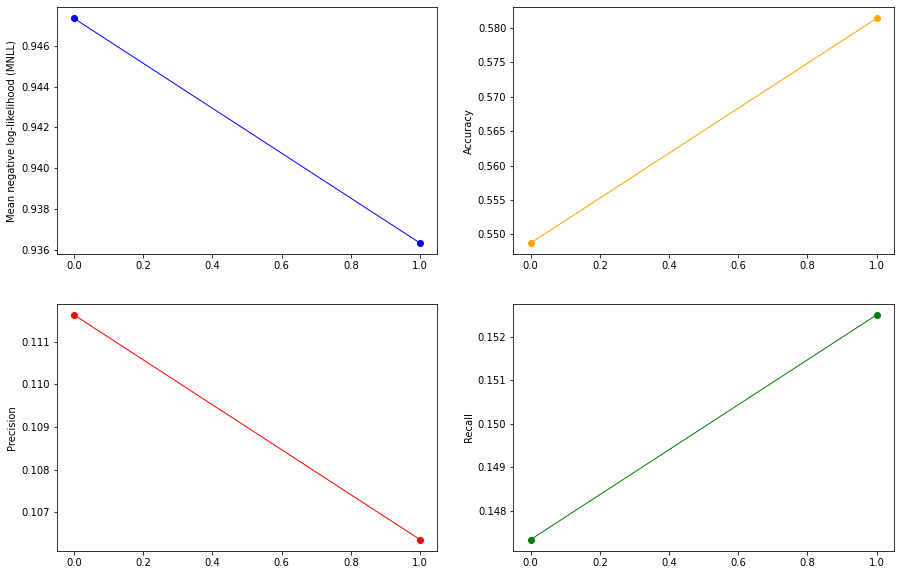

In [103]:
mnl_model.plot_training_results()

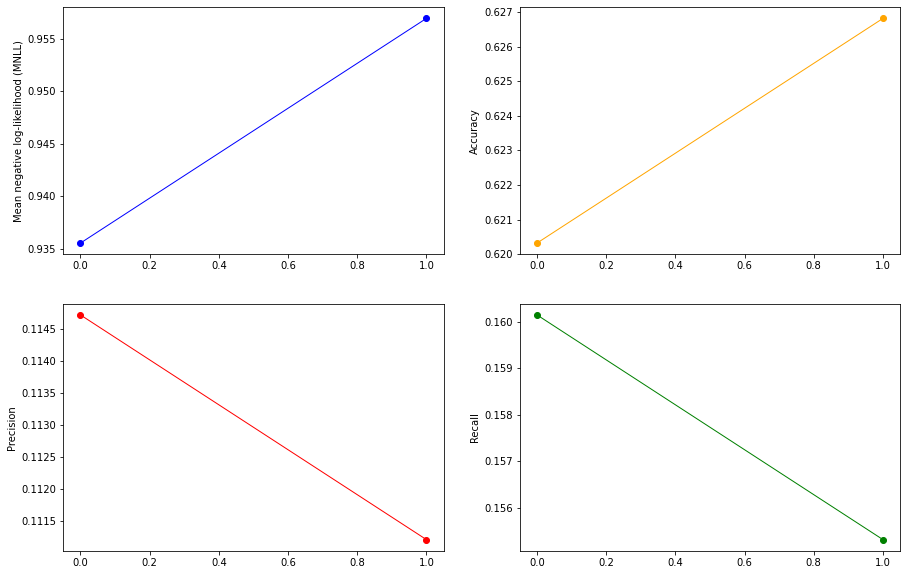

In [104]:
mnl_model.plot_testing_results()

In [105]:
mnl_model.get_model_parameters('car')

Paramters of generic variables for class car:
AGE: -118.8550033569336
INCOME: -118.36000061035156
trip_duration: -117.78500366210938
Early_morning_departure: -4.513999938964844
AM_peak_departure: -117.9219970703125
Off_peak_departure: -116.81500244140625
PM_peak_departure: -117.9229965209961
Night_departure: -88.197998046875
Purpose_101: -117.50399780273438
Purpose_998: -117.91300201416016
Purpose_100: -88.36199951171875
Purpose_300: -111.6520004272461
Purpose_200: -99.68199920654297
Purpose_400: -115.9000015258789
Purpose_600: -98.697998046875
Purpose_500: -114.61699676513672
Purpose_202: 103.89700317382812
Purpose_201: -105.60199737548828
Purpose_999: 0.30300000309944153
Male: -117.71800231933594
Female: -117.5719985961914
job_type_company employee: 17.49799919128418
job_type_Part time job: -106.80400085449219
job_type_Management executive: 0.5759999752044678
job_type_civil servant: -116.80699920654297
job_type_Housewife: -113.14900207519531
job_type_Self employed/ Freelance: 4.95900

In [106]:
mnl_model.get_model_parameters('train')

Paramters of generic variables for class train:
AGE: 122.46099853515625
INCOME: 121.58799743652344
trip_duration: 121.29499816894531
Early_morning_departure: -11.918999671936035
AM_peak_departure: 120.47000122070312
Off_peak_departure: 130.2550048828125
PM_peak_departure: 120.69400024414062
Night_departure: -95.03500366210938
Purpose_101: 119.83200073242188
Purpose_998: 119.57599639892578
Purpose_100: 120.21399688720703
Purpose_300: 116.17500305175781
Purpose_200: -53.61600112915039
Purpose_400: -107.48500061035156
Purpose_600: 101.8280029296875
Purpose_500: 118.77200317382812
Purpose_202: -114.08300018310547
Purpose_201: -56.79600143432617
Purpose_999: 3.552999973297119
Male: 120.47100067138672
Female: 121.89299774169922
job_type_company employee: 45.98699951171875
job_type_Part time job: 112.36000061035156
job_type_Management executive: 2.9119999408721924
job_type_civil servant: 120.25900268554688
job_type_Housewife: -99.65599822998047
job_type_Self employed/ Freelance: 14.0609998703

In [122]:
# Utility of classes w.r.t 'car' class

class_label='bus'
class_index = output_categories.index(class_label)
mnl_model(X_train.to_numpy()).numpy()[:, class_index].mean()

0.39351353